In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Teorie
    síla = hmotnost * zrychlení : F=m*a
    -> m = 1 -> F=a (zrychlení se rovná součtu všech sil které na něj působí)
    poloha - x, rychlost - v (derivace polohy x), zrychlení - a (derivace rychlosti v, nebo druhá derivace polohy x)

    --pružina
    x¨ + δx˙ + αx = 0
    x¨ = -δx˙ - αx

    tlumení = -δx˙
    pružení = -αx

    --duffing
    x¨ + δx˙ + αx + βx**3 = γcos(ωt)
    x¨ = -δx˙ -αx -βx**3 + γcos(ωt) /(přepíšeme na veličiny)
    a = γcos(ωt) - δv - αx - βx**3 /(pojmenujeme členy)

    buzení = γcos(ωt) (vnější strkání, gama - síla strčení, ω - jak rychle strkám)
    tlumení = -δv (odpor prostředí, delta - jak moc husté je prostředí)
    pružení = - αx - βx**3 (alfa - tuhost pružiny, x**3 - nelineární člen, beta - jak se materiál chová když se hodně natáhne (<1 - měknoucí, >1 - tvrdnoucí))
    a = buzení + tlumení + pružení /(finální tvar)

In [2]:
# --- 1. DEFINICE OSCILÁTORŮ ---

def linearni_oscilator(t, y, delta, alfa):
    x, v = y #poloha a  rychlost
    dxdt = v # změna polohy - rychlost -> vezme se aktuální rychlost, posune se podle ní poloha
    dvdt = -delta * v - alfa * x #změna rychlosti - zrychlení -> spočítání všech sil reps. zrychlení a posunutí rychlosti
    return [dxdt, dvdt]

def duffing_oscilator(t, y, delta, alfa, beta, gama, omega):
    x, v = y
    dxdt = v
    dvdt = gama * np.cos(omega * t) - delta * v - alfa * x - beta * x**3
    return [dxdt, dvdt]

In [7]:
# --- 2. NASTAVENÍ A SIMULACE ---

# Počáteční podmínky ke zkoumání: [poloha, rychlost]
pocatecni_podminky = [
    [1.0, 1.0],  # nenulové obě
    [1.0, 0.0],  # nenulová výchylka, nulová rychlost
    [0.0, 1.0]   # nulová výchylka, nenulová rychlost
]

# Čas simulace - doporučeno delší pro Duffinga kvůli chaosu a Poincarého mapě
t_max = 500
t_eval = np.linspace(0, t_max, 15000) # Husté vzorkování pro hladké grafy x(t)

# Parametry Duffing z doporučení
delta_d = 0.2 #hustota prostředí pro tlumení
alfa_d = -1.0 #tuhost pružiny
beta_d = 1.0 #jak se chová při velkém natažení <1 softening, >1 hardening
gama_d = 0.3 #síla strkání
omega_d = 1.2 #frekvence strkání

# Parametry pro lineární (podobné, ale bez nelineárního a budícího členu)
delta_l = 0.2
alfa_l = 1.0 # Kladná tuhost pro normální pružinu

# Vypočet periody pro Poincarého řez (Duffing)
T = 2 * np.pi / omega_d #perioda strkání
t_poincare = np.arange(0, t_max, T) #kdy se strčí, v jaký moment

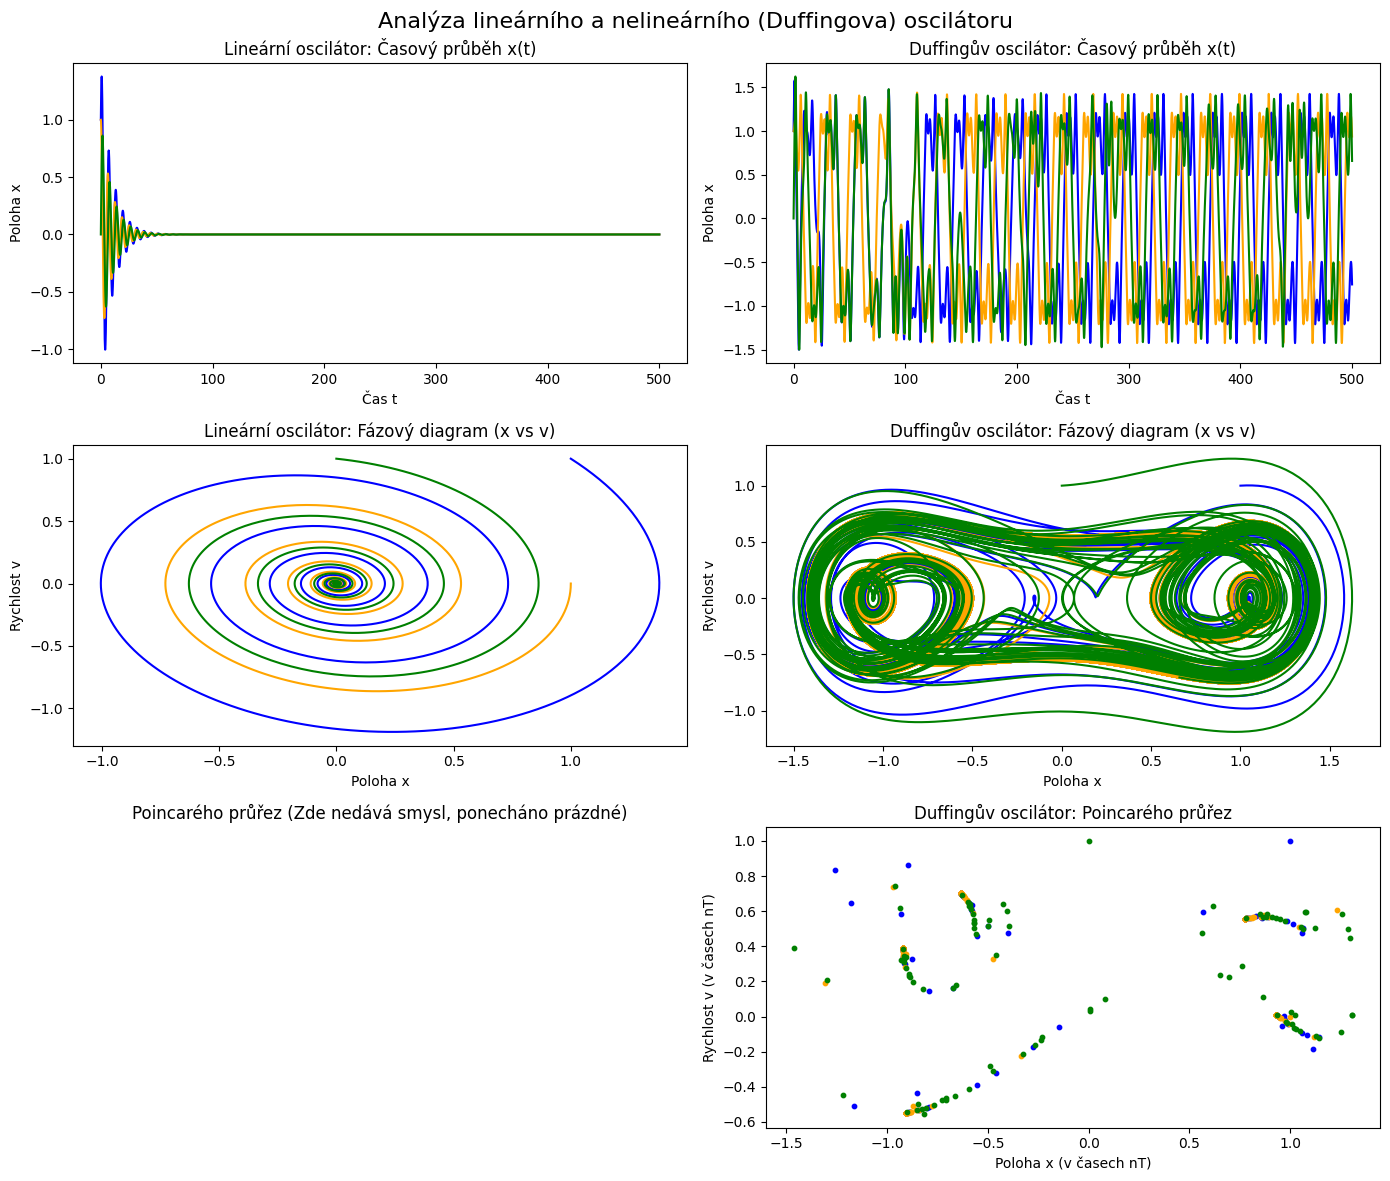

In [9]:
# Příprava grafů: 3 řádky (x(t), fázový prostor, Poincaré), 2 sloupce (Lineární, Duffing)
fig, axs = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("Analýza lineárního a nelineárního (Duffingova) oscilátoru", fontsize=16) #nadpis grafu

# Barvy pro různé počáteční podmínky
barvy = ['blue', 'orange', 'green']

for i, (x0, v0) in enumerate(pocatecni_podminky): #procházení všech počátečních podmínek - rychlost a poloha (výchylka)
      y0 = [x0, v0]

      # --- A) ŘEŠENÍ LINEÁRNÍHO OSCILÁTORU ---
      sol_lin = solve_ivp(
          linearni_oscilator, [0, t_max], y0, t_eval=t_eval, #oscilátor, čas, počáteční podmínky, vzorkování
          args=(delta_l, alfa_l), rtol=1e-8, atol=1e-10 #delta a alfa, jak moc se může splést
      )

      # Vykreslení Lineární x(t)
      axs[0, 0].plot(sol_lin.t, sol_lin.y[0], color=barvy[i], label=f'x0={x0}, v0={v0}')
      # Vykreslení Lineární Fázový prostor (x vs v)
      axs[1, 0].plot(sol_lin.y[0], sol_lin.y[1], color=barvy[i])

      # --- B) ŘEŠENÍ DUFFINGOVA OSCILÁTORU ---
      sol_duf = solve_ivp(
          duffing_oscilator, [0, t_max], y0, t_eval=t_eval, dense_output=True,
          args=(delta_d, alfa_d, beta_d, gama_d, omega_d), rtol=1e-8, atol=1e-10
      )

      # Vykreslení Duffing x(t)
      axs[0, 1].plot(sol_duf.t, sol_duf.y[0], color=barvy[i], label=f'x0={x0}, v0={v0}')
      # Vykreslení Duffing Fázový prostor (x vs v)
      axs[1, 1].plot(sol_duf.y[0], sol_duf.y[1], color=barvy[i])

      # Vykreslení Duffing Poincarého průřez
      # Z řešení (dense_output) vytáhneme přesné hodnoty v časech t = nT
      poincare_stavy = sol_duf.sol(t_poincare)
      axs[2, 1].scatter(poincare_stavy[0], poincare_stavy[1], color=barvy[i], s=10)

# --- ÚPRAVA VZHLEDU GRAFŮ ---
# Lineární sloupec
axs[0, 0].set_title("Lineární oscilátor: Časový průběh x(t)")
axs[0, 0].set_xlabel("Čas t")
axs[0, 0].set_ylabel("Poloha x")

axs[1, 0].set_title("Lineární oscilátor: Fázový diagram (x vs v)")
axs[1, 0].set_xlabel("Poloha x")
axs[1, 0].set_ylabel("Rychlost v")

axs[2, 0].set_title("Poincarého průřez (Zde nedává smysl, ponecháno prázdné)")
axs[2, 0].axis('off') # Lineární autonomní systém nemá smysl vzorkovat Poincarém, bylo by pouze pár bodů v podobném místě

# Duffingův sloupec
axs[0, 1].set_title("Duffingův oscilátor: Časový průběh x(t)")
axs[0, 1].set_xlabel("Čas t")
axs[0, 1].set_ylabel("Poloha x")

axs[1, 1].set_title("Duffingův oscilátor: Fázový diagram (x vs v)")
axs[1, 1].set_xlabel("Poloha x")
axs[1, 1].set_ylabel("Rychlost v")

axs[2, 1].set_title("Duffingův oscilátor: Poincarého průřez")
axs[2, 1].set_xlabel("Poloha x (v časech nT)")
axs[2, 1].set_ylabel("Rychlost v (v časech nT)")

plt.tight_layout()
plt.show()

# Otázky

    Otázky (odpovězte v textu)
    A) Lineární oscilátor
    • Co odlišuje slabé (underdamped), kritické (critical) a silné (overdamped) tlumení?
        Odlišují se ve schopnosti kmitat.
        Při slabém tlumení systém překmitává přes rovnovážnou polohu a jeho amplituda se pomalu blíží k nule.
        Při kritickém se systém vrátí do rovnovážné polohy v nejkratším možném čase bez kmitání.
        Při silném se velmi pomalu blíží rovnovážné poloze bez kmitání.
        V mých grafech je slabé tlumení, systém osciluje.
    
    • Jak se změní chování systému, pokud změníme tlumení o několik procent? Je přechod mezi režimy plynulý nebo
    kvalitativně ostrý?
        Pokud změnu provedu uvnitř jednoho režimu, např. ve slabém tlumení, tak je změna plynulá.
        Pokud jsem na hranici kritického tlumení, tak je změna kvalitativně ostrá protože začne kmitat.
    
    • Jaký mechanismus vede k rezonanci u buzeného kmitání?
        Pokud dodávám vnější buzení přesně v přirozené frekvenci oscilátoru. Amplituda začne narůstat.
    
    • Dá se problém řešit pomocí symbolické matematiky? Jak?
        Ano dá. V pythonu pomocí knihovny sympy, která místo bodů pro graf vrátí vzorec pro funcki, do které stačí dosadit čas.

    B) Duffing
    • Dochází pro dané parametry k chaotickému chování?
        Ano. Důkazem jsou grafy. Fázový tvoří nepravidelné zamotané klubko a Poincarého průřez vykresluje složitou strukturu bodů.
    
    • Jaký je rozdíl mezi malou a velkou počáteční podmínkou?
        V netlumeném systému malá poč. podmínka způsobí uvíznutí v jednom lokálním atraktoru a velká umožní středovou bariéru přeskakovat.
        V chaotickém režimu změna počáteční podmínky způsobí tzv. motýlí efekt - systémy s nepatrně odlišným startem se rychle rozejdou a jejich čas. průběhy se úplně liší.
    
    • Co se stane, když zvýšíte buzení γ?
        Dáváme do systému více energie. Systém se tedy může skokově přepínat z periodického pohybu až do chaosu.
    
    • Mění se počet atraktorů?
        Ano. Bez buzení má systém dva bodové atraktory. Při chaosu se spojí do jednoho velkého podivného atraktoru.